# Linear Regression on Network Traffic

In this hands-on assignment, we will explore learn models, in particular linear regression. Linear models can work well when there is a linear relationship between the target variable being predicted and the input features. In other words, when the target prediction can be modeled as a linear combination of the input features, linear models may be appropriate.

We'll explore the relationship beween bytes and packets in this hands-on, which may have a linear relationship at times. We will also explore how basis expansion---in particular polynomial basis expansion---can allow linear regression to fit more complex relationships between features and targets.

In [1]:
# Machine Learning Libraries
import numpy as np
import pandas as pd
from sklearn import linear_model

import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

import sys
sys.path.insert(1,"/Users/feamster/research/netml/src/")
from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

# Plotting Library
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (8,6)

/Users/chrislowzx/miniconda3/envs/netml-311/lib/python3.11/site-packages/scapy/layers/ipsec.py:512: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  cipher=algorithms.TripleDES,
/Users/chrislowzx/miniconda3/envs/netml-311/lib/python3.11/site-packages/scapy/layers/ipsec.py:516: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  cipher=algorithms.TripleDES,



## Part 1: Simple Linear Regression.

### Group Traffic Info Flows 

This example below uses a packet capture that is provided in the repository. You are also welcome (and encouraged!) to capture your own traffic.

Use `netml` to load the pcap and convert packets to flows, using pcap2flows.

In [2]:
hpcap = PCAP('data/http.pcap', flow_ptks_thres=2, verbose=10)
hpcap.pcap2flows()
len(hpcap.flows)

pcap_file: data/http.pcap
ith_packets: 0
ith_packets: 10000
ith_packets: 20000
len(flows): 593
total number of flows: 593. Num of flows < 2 pkts: 300, and >=2 pkts: 293 without timeout splitting.
kept flows: 293. Each of them has at least 2 pkts after timeout splitting.
flow_durations.shape: (293, 1)
        col_0
count 293.000
mean   11.629
std    15.820
min     0.000
25%     0.076
50%     0.455
75%    20.097
max    46.235
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col_0   293 non-null    float64
dtypes: float64(1)
memory usage: 2.4 KB
None
0th_flow: len(pkts): 4
After splitting flows, the number of subflows: 291 and each of them has at least 2 packets.


291

### Generate Features

Use the `netml` "STATS" option to generate features for each flow, which will provide the following features for each flow:

0. Duration
1. Packets per second
2. Bytes per second
3. Mean packet size
4. Standard deviation of packet sizes
5. 25th, median, 75th, min, max packet sizes

The exercise below requires a [slight modification](https://github.com/chicago-cdac/netml/pull/16/commits/79c0f930f2882c7bf042a9eb45e2a6ac413a695d) to the `netml` library (for versions <= 0.2.1) to add two additional features:
* number of packets per flow
* number of bytes per flow

You can modify the library (line 455 of `parser.py`) to add total number of packets and bytes per flow, or optionally explore the relationships between some of the other features.

In [3]:
# Generate features using STATS
from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

# Extract features using STATS method
hpcap.flow2features(fft='stats', header=False)

# Convert to pandas DataFrame for easier manipulation
import pandas as pd
df = pd.DataFrame(hpcap.features)

# Display first few rows to see what features we have
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

False
Shape: (291, 92)
Columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91]


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91
0,30.076,30.006,29.796,29.446,28.958,28.336,27.581,26.697,25.689,24.561,23.318,21.967,20.513,18.964,17.327,15.609,13.819,11.965,10.056,8.100,6.108,4.087,2.048,0.000,-2.047,-4.084,-6.101,-8.089,-10.039,-11.941,-13.787,-15.569,-17.277,-18.905,-20.444,-21.888,-23.229,-24.462,-25.581,-26.581,-27.457,-28.205,-28.822,-29.305,-29.651,-29.860,-29.929,-29.860,-29.651,-29.305,-28.822,-28.205,-27.457,-26.581,-25.581,-24.462,-23.229,-21.888,-20.444,-18.905,-17.277,-15.569,-13.787,-11.941,-10.039,-8.089,-6.101,-4.084,-2.047,0.000,2.048,4.087,6.108,8.100,10.056,11.965,13.819,15.609,17.327,18.964,20.513,21.967,23.318,24.561,25.689,26.697,27.581,28.336,28.958,29.446,29.796,30.006
1,30.060,29.989,29.779,29.430,28.943,28.322,27.568,26.685,25.678,24.552,23.311,21.961,20.508,18.961,17.325,15.608,13.819,11.966,10.057,8.102,6.109,4.088,2.048,-0.000,-2.049,-4.087,-6.107,-8.097,-10.049,-11.954,-13.803,-15.588,-17.299,-18.930,-20.472,-21.919,-23.263,-24.499,-25.621,-26.623,-27.502,-28.252,-28.870,-29.354,-29.702,-29.911,-29.981,-29.911,-29.702,-29.354,-28.870,-28.252,-27.502,-26.623,-25.621,-24.499,-23.263,-21.919,-20.472,-18.930,-17.299,-15.588,-13.803,-11.954,-10.049,-8.097,-6.107,-4.087,-2.049,-0.000,2.048,4.088,6.109,8.102,10.057,11.966,13.819,15.608,17.325,18.961,20.508,21.961,23.311,24.552,25.678,26.685,27.568,28.322,28.943,29.430,29.779,29.989
2,40.960,40.696,39.910,38.626,36.878,34.714,32.193,29.384,26.362,23.205,19.995,16.812,13.734,10.832,8.171,5.806,3.781,2.129,0.871,0.014,-0.445,-0.521,-0.241,0.363,1.249,2.370,3.676,5.117,6.642,8.203,9.755,11.260,12.683,13.999,15.189,16.241,17.150,17.917,18.548,19.055,19.450,19.748,19.966,20.118,20.217,20.272,20.290,20.272,20.217,20.118,19.966,19.748,19.450,19.055,18.548,17.917,17.150,16.241,15.189,13.999,12.683,11.260,9.755,8.203,6.642,5.117,3.676,2.370,1.249,0.363,-0.241,-0.521,-0.445,0.014,0.871,2.129,3.781,5.806,8.171,10.832,13.734,16.812,19.995,23.205,26.362,29.384,32.193,34.714,36.878,38.626,39.910,40.696
3,40.962,40.697,39.909,38.620,36.866,34.696,32.168,29.351,26.320,23.156,19.939,16.751,13.669,10.765,8.104,5.741,3.720,2.074,0.822,-0.026,-0.475,-0.542,-0.252,0.361,1.255,2.382,3.693,5.136,6.661,8.218,9.763,11.258,12.668,13.969,15.141,16.173,17.061,17.806,18.415,18.900,19.275,19.555,19.757,19.896,19.985,20.034,20.050,20.034,19.985,19.896,19.757,19.555,19.275,18.900,18.415,17.806,17.061,16.173,15.141,13.969,12.668,11.258,9.763,8.218,6.661,5.136,3.693,2.382,1.255,0.361,-0.252,-0.542,-0.475,-0.026,0.822,2.074,3.720,5.741,8.104,10.765,13.669,16.751,19.939,23.156,26.320,29.351,32.168,34.696,36.866,38.620,39.909,40.697
4,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058,0.058


### Train Model

Explore the relationship between some of these features. A natural one to explore is the relationship between the number of bytes in a flow and the number of packets in a flow.

In [5]:
# Explore the relationship between bytes and packets
# Note: The netml library may need modification to include total packets and bytes
# Let's first look at some sample data to understand the features

print("Sample of features (first 5 rows, first 15 columns):")
print(df.iloc[:5, :15])

print("\n\nFeature statistics (first 15 columns):")
print(df.iloc[:, :15].describe())

# Based on netml documentation, features typically include:
# - Duration, packets/sec, bytes/sec, mean, std, percentiles, etc.
# We need to identify which columns have total packets and total bytes

Sample of features (first 5 rows, first 15 columns):
      0      1      2      3      4      5      6      7      8      9      10     11     12  \
0 30.076 30.006 29.796 29.446 28.958 28.336 27.581 26.697 25.689 24.561 23.318 21.967 20.513   
1 30.060 29.989 29.779 29.430 28.943 28.322 27.568 26.685 25.678 24.552 23.311 21.961 20.508   
2 40.960 40.696 39.910 38.626 36.878 34.714 32.193 29.384 26.362 23.205 19.995 16.812 13.734   
3 40.962 40.697 39.909 38.620 36.866 34.696 32.168 29.351 26.320 23.156 19.939 16.751 13.669   
4  0.058  0.058  0.058  0.058  0.058  0.058  0.058  0.058  0.058  0.058  0.058  0.058  0.058   

      13     14  
0 18.964 17.327  
1 18.961 17.325  
2 10.832  8.171  
3 10.765  8.104  
4  0.058  0.058  


Feature statistics (first 15 columns):
           0       1       2       3       4       5       6       7       8       9       10  \
count 291.000 291.000 291.000 291.000 291.000 291.000 291.000 291.000 291.000 291.000 291.000   
mean   10.736   9.127   6.7

Train a `Linear Regression` model from scikit learn to model this relationship, and output the resulting predictions into a vector `y_hat`.

In [7]:
# Train a Linear Regression model
from sklearn.linear_model import LinearRegression

# Let's use a different approach - calculate packets and bytes from the flows directly
# Extract packet and byte counts from each flow
packets_list = []
bytes_list = []

for flow_data in hpcap.flows:
    pkts = flow_data[1]  # packets in the flow
    num_packets = len(pkts)
    num_bytes = sum(len(pkt) for pkt in pkts)
    packets_list.append(num_packets)
    bytes_list.append(num_bytes)

# Convert to numpy arrays
X = np.array(packets_list).reshape(-1, 1)  # Number of packets
y = np.array(bytes_list)  # Number of bytes

print(f"Number of flows: {len(X)}")
print(f"Packets range: {X.min()} to {X.max()}")
print(f"Bytes range: {y.min()} to {y.max()}")

# Train the model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_hat = model.predict(X)

# Display model parameters
print(f"\nCoefficient (slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Model equation: y = {model.coef_[0]:.2f} * x + {model.intercept_:.2f}")
print(f"\nInterpretation: On average, each packet contains {model.coef_[0]:.2f} bytes")

Number of flows: 291
Packets range: 2 to 2985
Bytes range: 120 to 4464796

Coefficient (slope): 1447.22
Intercept: -21680.35
Model equation: y = 1447.22 * x + -21680.35

Interpretation: On average, each packet contains 1447.22 bytes


### Visualize Your Model

Plot the relationship that your model has learned, by plotting the learned model (which should be a line), along with the points.  Label your axes!

What do you notice about the relationship, and how it relates to the original points?

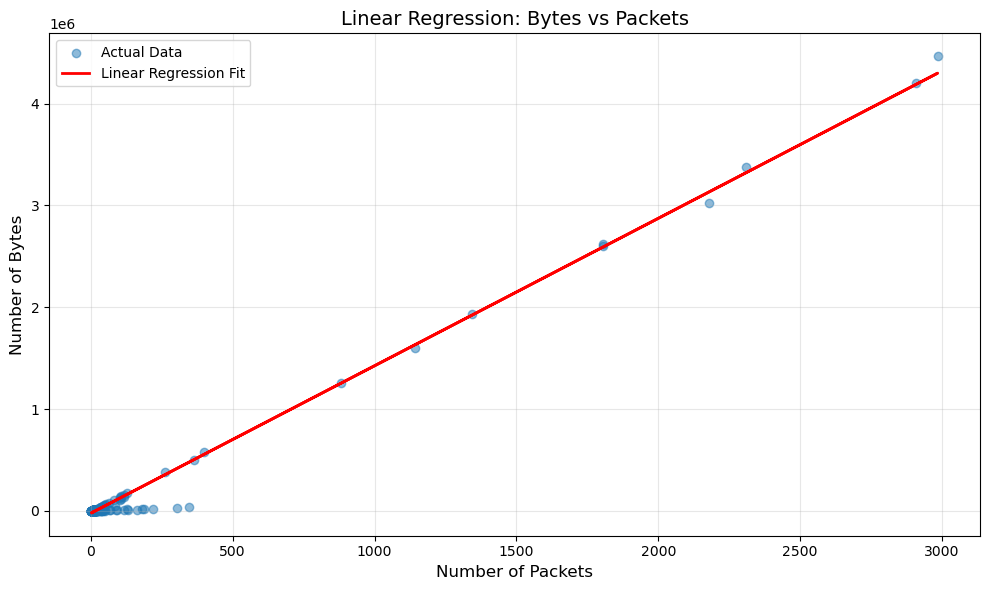


Observations:
The linear relationship shows that as the number of packets increases,
the number of bytes increases proportionally. The slope represents the
average bytes per packet across all flows.


In [8]:
# Visualize the model
plt.figure(figsize=(10, 6))

# Plot actual data points
plt.scatter(X, y, alpha=0.5, label='Actual Data')

# Plot the regression line
plt.plot(X, y_hat, color='red', linewidth=2, label='Linear Regression Fit')

# Labels and title
plt.xlabel('Number of Packets', fontsize=12)
plt.ylabel('Number of Bytes', fontsize=12)
plt.title('Linear Regression: Bytes vs Packets', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservations:")
print("The linear relationship shows that as the number of packets increases,")
print("the number of bytes increases proportionally. The slope represents the")
print("average bytes per packet across all flows.")

### Evaluation: Error Computation

You can compute how well your manual fit is by computing the error, in terms of residual sum of squares.

In [9]:
# Compute error metrics
from sklearn.metrics import mean_squared_error, r2_score

# Calculate residual sum of squares
rss = np.sum((y - y_hat) ** 2)

# Calculate mean squared error
mse = mean_squared_error(y, y_hat)

# Calculate R-squared
r2 = r2_score(y, y_hat)

print(f"Residual Sum of Squares (RSS): {rss:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse):.2f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"\nThe R² value of {r2:.4f} means that {r2*100:.2f}% of the variance")
print("in bytes is explained by the number of packets.")

Residual Sum of Squares (RSS): 756516822104.06
Mean Squared Error (MSE): 2599714165.31
Root Mean Squared Error (RMSE): 50987.39
R-squared (R²): 0.9903

The R² value of 0.9903 means that 99.03% of the variance
in bytes is explained by the number of packets.


## Part 2: Polynomial Basis Expansion

Recall that one of the benefits of a polynomial feature expansion is that it is possible to fit a linear model to a resulting polynomial expansion of the features.

We will do that below.  Let's first create the regular features and then the polynomial expansion. You will need the `PolynomialFeatures` library from `sklearn.preprocessing`, as well as the `fit_transform` function to generate your feature expansion.

In [10]:
# Create polynomial features
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features of degree 2
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

print(f"Original features shape: {X.shape}")
print(f"Polynomial features shape: {X_poly.shape}")
print(f"Feature names: {poly.get_feature_names_out(['packets'])}")

Original features shape: (291, 1)
Polynomial features shape: (291, 3)
Feature names: ['1' 'packets' 'packets^2']


Train the linear regression model on the expanded set of features, and generate a new set of predictions, `y_hat_poly`.

In [11]:
# Train linear regression on polynomial features
model_poly = LinearRegression()
model_poly.fit(X_poly, y)

# Make predictions
y_hat_poly = model_poly.predict(X_poly)

# Display model parameters
print(f"Intercept: {model_poly.intercept_:.2f}")
print(f"Coefficients: {model_poly.coef_}")
print(f"\nModel equation: y = {model_poly.coef_[0]:.2f} + {model_poly.coef_[1]:.2f}*x + {model_poly.coef_[2]:.2f}*x²")

Intercept: -16040.33
Coefficients: [0.00000000e+00 1.24552466e+03 8.49957477e-02]

Model equation: y = 0.00 + 1245.52*x + 0.08*x²


Visualize your results again. What do you notice about the predicted values?

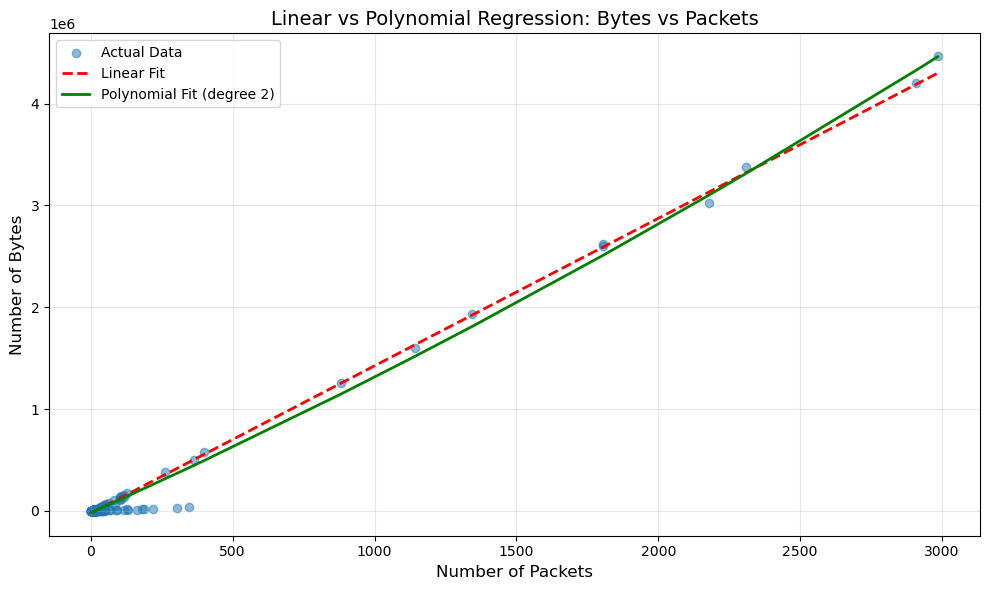


Observations:
The polynomial fit can capture non-linear relationships in the data.
It may fit the training data better than the linear model, but could
also be more prone to overfitting.


In [12]:
# Visualize polynomial regression results
plt.figure(figsize=(10, 6))

# Sort data for smooth curve plotting
sort_idx = np.argsort(X.flatten())
X_sorted = X[sort_idx]
y_sorted = y[sort_idx]
y_hat_poly_sorted = y_hat_poly[sort_idx]

# Plot actual data points
plt.scatter(X, y, alpha=0.5, label='Actual Data')

# Plot the linear regression line
plt.plot(X_sorted, model.predict(X_sorted), color='red', linewidth=2, label='Linear Fit', linestyle='--')

# Plot the polynomial regression curve
plt.plot(X_sorted, y_hat_poly_sorted, color='green', linewidth=2, label='Polynomial Fit (degree 2)')

# Labels and title
plt.xlabel('Number of Packets', fontsize=12)
plt.ylabel('Number of Bytes', fontsize=12)
plt.title('Linear vs Polynomial Regression: Bytes vs Packets', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservations:")
print("The polynomial fit can capture non-linear relationships in the data.")
print("It may fit the training data better than the linear model, but could")
print("also be more prone to overfitting.")

Evaluate your error once again. What happened to overall mean squared error?

In [13]:
# Evaluate polynomial model error
rss_poly = np.sum((y - y_hat_poly) ** 2)
mse_poly = mean_squared_error(y, y_hat_poly)
r2_poly = r2_score(y, y_hat_poly)

print("Linear Regression Results:")
print(f"  MSE: {mse:.2f}")
print(f"  R²: {r2:.4f}")

print("\nPolynomial Regression Results:")
print(f"  MSE: {mse_poly:.2f}")
print(f"  R²: {r2_poly:.4f}")

print("\nComparison:")
print(f"  MSE Reduction: {mse - mse_poly:.2f} ({(mse - mse_poly)/mse * 100:.2f}%)")
print(f"  R² Improvement: {r2_poly - r2:.4f}")

if mse_poly < mse:
    print("\nThe polynomial model has lower MSE, indicating better fit to the training data.")
else:
    print("\nThe linear model performs similarly or better, suggesting the relationship is linear.")

Linear Regression Results:
  MSE: 2599714165.31
  R²: 0.9903

Polynomial Regression Results:
  MSE: 2185055900.11
  R²: 0.9918

Comparison:
  MSE Reduction: 414658265.19 (15.95%)
  R² Improvement: 0.0016

The polynomial model has lower MSE, indicating better fit to the training data.


## Part 3: Exploring Relationships between Other Features

In the earlier parts of this hands-on, we explored simple relationship between features and outcome variables. You can extend your analysis by exploring other relationships, such as the relationships between one or more of the features already output from `netml`.

Feature DataFrame:
       packets       bytes  avg_packet_size  log_packets  log_bytes
count  291.000     291.000          291.000      291.000    291.000
mean    84.165  100124.914          345.198        2.698      7.932
std    355.977  517703.464          387.674        1.308      2.025
min      2.000     120.000           60.000        1.099      4.796
25%      6.000     945.000           96.648        1.946      6.852
50%     11.000    2053.000          152.143        2.485      7.628
75%     16.500    6134.000          432.292        2.862      8.722
max   2985.000 4464796.000         1495.744        8.002     15.312


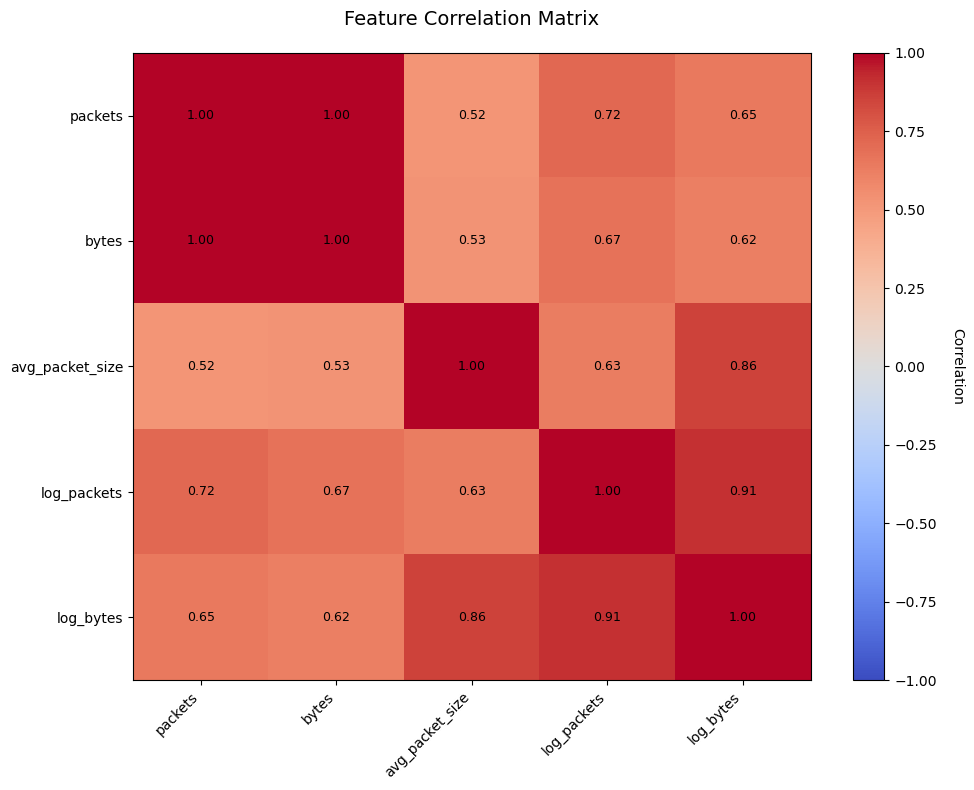


Features with high correlation might have strong linear relationships.

Correlation between packets and bytes: 0.9951


In [16]:
# Explore other feature relationships
# Let's create a simpler correlation analysis with the features we already have

# Create a dataframe with our basic features
feature_df = pd.DataFrame({
    'packets': packets_list,
    'bytes': bytes_list,
    'avg_packet_size': [b/p if p > 0 else 0 for b, p in zip(bytes_list, packets_list)]
})

# Add some derived features
feature_df['log_packets'] = np.log1p(feature_df['packets'])
feature_df['log_bytes'] = np.log1p(feature_df['bytes'])

print("Feature DataFrame:")
print(feature_df.describe())

# Correlation matrix using matplotlib
corr_matrix = feature_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation', rotation=270, labelpad=20)

# Annotate with values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=9)

plt.title('Feature Correlation Matrix', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\nFeatures with high correlation might have strong linear relationships.")
print(f"\nCorrelation between packets and bytes: {corr_matrix.loc['packets', 'bytes']:.4f}")

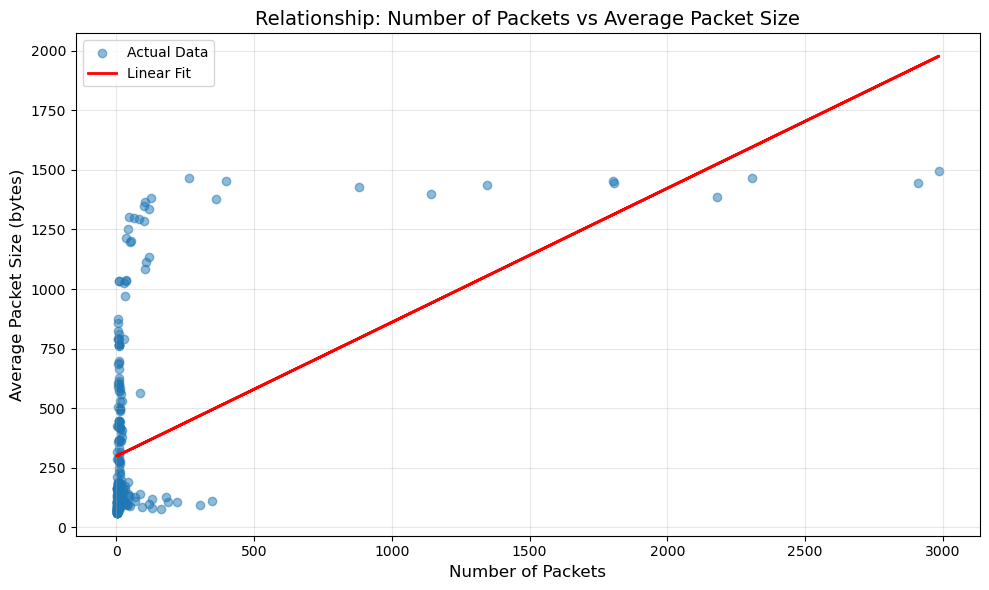

R² Score: 0.2671
This relationship explains 26.71% of the variance.

Weak correlation - there's little linear relationship between these features.


In [18]:
# Example: Explore relationship between packets and average packet size
X_explore = feature_df['packets'].values.reshape(-1, 1)
y_explore = feature_df['avg_packet_size'].values

# Train model
model_explore = LinearRegression()
model_explore.fit(X_explore, y_explore)
y_hat_explore = model_explore.predict(X_explore)

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_explore, y_explore, alpha=0.5, label='Actual Data')
plt.plot(X_explore, y_hat_explore, color='red', linewidth=2, label='Linear Fit')
plt.xlabel('Number of Packets', fontsize=12)
plt.ylabel('Average Packet Size (bytes)', fontsize=12)
plt.title('Relationship: Number of Packets vs Average Packet Size', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluate
r2_explore = r2_score(y_explore, y_hat_explore)
print(f"R² Score: {r2_explore:.4f}")
print(f"This relationship explains {r2_explore*100:.2f}% of the variance.")

if abs(r2_explore) < 0.5:
    print("\nWeak correlation - there's little linear relationship between these features.")
else:
    print(f"\nModerate correlation - packet count {'positively' if model_explore.coef_[0] > 0 else 'negatively'} correlates with average packet size.")

## Bonus: Reducing Error on Test Set

In the above example, we used a polynomial basis expansion to reduce the error on the training set. But, we have no test set, so it is difficult to tell whether the model above is overfit to the training data.

In order for us to tell whether this model is a good fit, we need to test it on data that the model has not yet seen. This requires splitting the data into a training set and a test set.

A typical split between training data and test data might be 80% training data, 20% test data. You can also perform this process repeatedly and average the results. This process is called **cross-validation**.

### Part 1

1. Take a packet trace using wireshark and load it into the notebook.
2. Perform a simple linear regression fit and a fit with basis expansion (same as above), comparing errors.

The first two steps are the same as above, but you might try doing this for a larger sample so that your network traffic has more flows (i.e., data points).

### Part 2

3. Use functions from sklearn to split the data into training and testing. (train_test_split, or sklearn's CV function).
4. How does model accuracy compare for different polynomial basis expansions? (n=1, 2, 3, ?) At what point is the model overfit?
5. Can you experiment with a regularization parameter to control or reduce overfitting?